# 수정


In [1]:
# 1. colab korean setting

!apt-get update -qq
!apt-get install -y fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import pandas as pd

# ✅ 2. 나눔고딕 폰트 등록 (한 번만 실행해도 됨)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)  # 시스템에 강제 등록
font_name = fm.FontProperties(fname=font_path).get_name()

# ✅ 3. 폰트 전역 설정
plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [2]:
# 2.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import sys
import os
import pandas as pd
import torch
import warnings
warnings.filterwarnings("ignore")

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import f1_score
from tqdm import tqdm

# 💣 1. 기존 패키지 제거 & 안정된 transformers 설치
!{sys.executable} -m pip uninstall -y peft sentence-transformers transformers tokenizers
!{sys.executable} -m pip install transformers==4.40.2

import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("📌 Using device:", device)
print("="*50)
print("✅ 환경 설정 완료 (transformers 4.40.2, seed 고정)")
print("📌 Using device:", device)
print("="*50)

Found existing installation: transformers 4.40.2
Uninstalling transformers-4.40.2:
  Successfully uninstalled transformers-4.40.2
Found existing installation: tokenizers 0.19.1
Uninstalling tokenizers-0.19.1:
  Successfully uninstalled tokenizers-0.19.1
  Using cached transformers-4.40.2-py3-none-any.whl.metadata (137 kB)
  Using cached tokenizers-0.19.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.7 kB)
Using cached transformers-4.40.2-py3-none-any.whl (9.0 MB)
Using cached tokenizers-0.19.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.6 MB)
📌 Using device: cuda
✅ 환경 설정 완료 (transformers 4.40.2, seed 고정)
📌 Using device: cuda


In [4]:
# 4. 데이터 로딩 및 전처리
DATA_DIR = "/content/drive/MyDrive/농담터"

def load_and_process(filepath):
    df = pd.read_csv(filepath, sep='\t', header=None, encoding='utf-8')
    df.columns = ["id", "text", "labels"]
    df["labels"] = df["labels"].apply(lambda x: list(map(int, str(x).split(","))))
    return df

train_df = load_and_process(f"{DATA_DIR}/train.tsv")
val_df = load_and_process(f"{DATA_DIR}/val.tsv")
test_df = load_and_process(f"{DATA_DIR}/test.tsv")

print(f"✅ Train: {len(train_df)} samples")
print(f"✅ Val: {len(val_df)} samples")
print(f"✅ Test: {len(test_df)} samples")

✅ Train: 40000 samples
✅ Val: 5000 samples
✅ Test: 5000 samples


In [5]:
# 5. 데이터 정의
class KoteDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=128, num_labels=44):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.num_labels = num_labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        text = row["text"]
        labels = row["labels"]

        label_tensor = torch.zeros(self.num_labels, dtype=torch.float)
        for label in labels:
            if 0 <= label < self.num_labels:
                label_tensor[label] = 1.0

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"][0],
            "attention_mask": encoding["attention_mask"][0],
            "labels": label_tensor
        }

In [6]:
# ✅ 6 모델 정의

# ✅ 저장 경로
MODEL_PATH = "/content/drive/MyDrive/농담터/model_finetuned"
os.makedirs(MODEL_PATH, exist_ok=True)

# ✅ 하이퍼파라미터
BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 2e-5
PATIENCE = 3
NUM_LABELS = 44
MAX_LENGTH = 128

# ✅ 디바이스 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ✅ 모델 및 토크나이저 로드
model_name = "snunlp/KR-ELECTRA-discriminator"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=NUM_LABELS)
model.to(device)

# ✅ 데이터셋 및 로더
train_dataset = KoteDataset(train_df, tokenizer, max_length=MAX_LENGTH, num_labels=NUM_LABELS)
val_dataset = KoteDataset(val_df, tokenizer, max_length=MAX_LENGTH, num_labels=NUM_LABELS)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ✅ 옵티마이저 설정
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at snunlp/KR-ELECTRA-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# 7 모델 학습
# ✅ 손실 함수 정의 (멀티라벨용)
criterion = torch.nn.BCEWithLogitsLoss()

# ✅ 경로 설정
model_path = "/content/drive/MyDrive/농담터"
best_model_dir = f"{model_path}/model_finetuned"
os.makedirs(model_path, exist_ok=True)
os.makedirs(best_model_dir, exist_ok=True)

# ✅ Early Stopping 변수 초기화
best_val_f1 = 0
counter = 0

for epoch in range(EPOCHS):
    print(f"\n🌱 Epoch {epoch + 1}/{EPOCHS}")
    model.train()
    epoch_loss = 0

    # ✅ 학습 루프
    for batch in tqdm(train_loader, desc="Training"):
        batch = {k: v.to(device) for k, v in batch.items()}
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["labels"]

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    print(f"🧠 Train Loss: {avg_train_loss:.4f}")

    # ✅ 검증 루프
    model.eval()
    preds, trues = [], []

    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            input_ids = batch["input_ids"]
            attention_mask = batch["attention_mask"]
            true_labels = batch["labels"]

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            pred_labels = (logits > 0.5).int().cpu().numpy()
            true_labels = true_labels.cpu().numpy()

            preds.extend(pred_labels)
            trues.extend(true_labels)

    val_f1 = f1_score(trues, preds, average="micro")
    print(f"🌸 Val F1 Score: {val_f1:.4f}")

    # 💾 모든 epoch 모델 저장 (.pt)
    torch.save(model.state_dict(), f"{model_path}/model_epoch{epoch + 1}.pt")

    # ✅ 가장 좋은 모델 저장 (Huggingface 포맷)
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        counter = 0
        print("✅ 성능 향상됨 → best 모델로 저장!")

        # Huggingface 포맷으로 저장 (폴더에)
        model.save_pretrained(best_model_dir)
        tokenizer.save_pretrained(best_model_dir)

        # ✅ best epoch 기록
        with open(f"{model_path}/best_epoch.txt", "w") as f:
            f.write(str(epoch + 1))
    else:
        counter += 1
        print(f"📉 성능 향상 없음: {counter}/{PATIENCE}")

        if counter >= PATIENCE:
            print("⛔ Early stopping triggered!")
            break

print("🎉 학습 완료!")

# ✅ 마지막 epoch 기록 (전체 로그)
with open(f"{model_path}/train_log.csv", "a") as f:
    f.write(f"{epoch + 1},{avg_train_loss:.4f},{val_f1:.4f}\n")


In [7]:
# 7 모델 학습 (이전 모델이므로 안 해도 됨)

# ✅ 손실 함수 정의 (멀티라벨용)
criterion = torch.nn.BCEWithLogitsLoss()

# ✅ 저장 경로 설정
model_path = "/content/drive/MyDrive/농담터"
os.makedirs(model_path, exist_ok=True)

# ✅ Early Stopping 변수 초기화
best_val_f1 = 0
counter = 0

for epoch in range(EPOCHS):
    print(f"\n🌱 Epoch {epoch + 1}/{EPOCHS}")
    model.train()
    epoch_loss = 0

    # ✅ 학습 루프
    for batch in tqdm(train_loader, desc="Training"):
        batch = {k: v.to(device) for k, v in batch.items()}
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["labels"]

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()


        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    print(f"🧠 Train Loss: {avg_train_loss:.4f}")

    # ✅ 검증 루프
    model.eval()
    preds, trues = [], []

    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            input_ids = batch["input_ids"]
            attention_mask = batch["attention_mask"]
            true_labels = batch["labels"]

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            pred_labels = (logits > 0.5).int().cpu().numpy()
            true_labels = true_labels.cpu().numpy()

            preds.extend(pred_labels)
            trues.extend(true_labels)

    val_f1 = f1_score(trues, preds, average="micro")
    print(f"🌸 Val F1 Score: {val_f1:.4f}")

    # 💾 매 Epoch마다 모델 저장 (.pt)
    torch.save(model.state_dict(), f"{model_path}/model_epoch{epoch + 1}.pt")

    # ✅ Early Stopping 조건 검사
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        counter = 0
        print("✅ 성능 향상됨. Huggingface 포맷으로 모델 저장!")

        model.save_pretrained(model_path)
        tokenizer.save_pretrained(model_path)
    else:
        counter += 1
        print(f"📉 성능 향상 없음. {counter}/{PATIENCE}")

        if counter >= PATIENCE:
            print("⛔ Early stopping triggered!")
            break

print("🎉 학습 완료!")

with open(f"{model_path}/train_log.csv", "a") as f:
    f.write(f"{epoch + 1},{avg_train_loss:.4f},{val_f1:.4f}\n")


🌱 Epoch 1/10


Training: 100%|██████████| 2500/2500 [14:28<00:00,  2.88it/s]


🧠 Train Loss: 0.3406
🌸 Val F1 Score: 0.4873
✅ 성능 향상됨. Huggingface 포맷으로 모델 저장!

🌱 Epoch 2/10


Training: 100%|██████████| 2500/2500 [14:31<00:00,  2.87it/s]


🧠 Train Loss: 0.2852
🌸 Val F1 Score: 0.5428
✅ 성능 향상됨. Huggingface 포맷으로 모델 저장!

🌱 Epoch 3/10


...

🧠 Train Loss: 0.1932
🌸 Val F1 Score: 0.6105
✅ 성능 향상됨. Huggingface 포맷으로 모델 저장!

🌱 Epoch 9/10


Training: 100%|██████████| 2500/2500 [14:31<00:00,  2.87it/s]


🧠 Train Loss: 0.1814
🌸 Val F1 Score: 0.6104
📉 성능 향상 없음. 1/3

🌱 Epoch 10/10


Training: 100%|██████████| 2500/2500 [14:30<00:00,  2.87it/s]


🧠 Train Loss: 0.1706
🌸 Val F1 Score: 0.6011
📉 성능 향상 없음. 2/3
🎉 학습 완료!


In [9]:
# 8 테스트

import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm

# ✅ 모델 경로
model_path = "/content/drive/MyDrive/농담터"

# ✅ 모델과 토크나이저 로드
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# ✅ 댓글 데이터 불러오기
df = pd.read_csv(f"{model_path}/only_comment.csv")

# ✅ 감정 분류 그룹 정의
positive_idx = [1, 2, 4, 8, 14, 15, 16, 19, 33, 41, 42, 43]
negative_idx = [0, 3, 5, 6, 10, 12, 20, 21, 22, 23, 25, 26, 27, 36, 38, 40]
neutral_idx  = [7, 9, 11, 13, 17, 18, 24, 28, 29, 30, 31, 32, 34, 35, 37, 39]

# ✅ 결과 저장 리스트
all_preds = []
all_summary = []

# ✅ 예측 실행
for comment in tqdm(df["comment"], desc="Predicting"):
    inputs = tokenizer(comment, return_tensors="pt", truncation=True, padding=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.sigmoid(logits).cpu().numpy()[0]

        preds = (probs > 0.5).astype(int).tolist()
        all_preds.append(preds)

        # ✅ 요약 감정 분류
        pos_score = sum([preds[i] for i in positive_idx])
        neg_score = sum([preds[i] for i in negative_idx])
        neu_score = sum([preds[i] for i in neutral_idx])

        if pos_score >= neg_score and pos_score >= neu_score:
            summary = "긍정"
        elif neg_score >= pos_score and neg_score >= neu_score:
            summary = "부정"
        else:
            summary = "중립"

        all_summary.append(summary)

        # ✅ print 출력
        print(f"\n🗨️ 댓글: {comment}")
        print(f"📊 예측 벡터: {preds}")
        print(f"🎯 요약 감정: {summary}")

# ✅ 결과 저장
df["predicted"] = all_preds
df["summary_emotion"] = all_summary
df.to_csv(f"{model_path}/predicted_result.csv", index=False)

print("\n✅ 전체 예측 완료! predicted_result.csv 파일로 저장됨")

Output hidden; open in https://colab.research.google.com to view.

# SNU VS Trained Model(Epoch8)

In [40]:
# ✅ 테스트용 데이터 (정답 포함)
test_df = load_and_process(f"{DATA_DIR}/test.tsv")

# ✅ 댓글만 추출
comments = test_df["text"].tolist()

# ✅ 정답 레이블: 첫 번째 감정만 추출
true_labels = test_df["labels"].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else -1)


In [41]:
def predict_single_label(model, tokenizer, comments):
    model.eval()
    model.to(device)
    preds = []

    for comment in tqdm(comments, desc="Predicting"):
        inputs = tokenizer(comment, return_tensors="pt", truncation=True, padding=True, max_length=128)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            probs = torch.sigmoid(logits).cpu().numpy()[0]
            pred_label = int(np.argmax(probs))  # 가장 확률 높은 감정 하나만 추출
            preds.append(pred_label)

    return preds


In [42]:
# ✅ snunlp 모델 (사전학습된)
model_snunlp = AutoModelForSequenceClassification.from_pretrained("snunlp/KR-ELECTRA-discriminator", num_labels=44)
tokenizer = AutoTokenizer.from_pretrained("snunlp/KR-ELECTRA-discriminator")
snunlp_preds = predict_single_label(model_snunlp, tokenizer, comments)

# ✅ 학습된 모델
model_epoch8 = AutoModelForSequenceClassification.from_pretrained(model_path)
epoch8_preds = predict_single_label(model_epoch8, tokenizer, comments)

# ✅ 평가
from sklearn.metrics import f1_score

f1_snunlp = f1_score(true_labels, snunlp_preds, average="micro")
f1_epoch8 = f1_score(true_labels, epoch8_preds, average="micro")

print(f"📊 snunlp F1 Score: {f1_snunlp:.4f}")
print(f"🌱 model_epoch8 F1 Score: {f1_epoch8:.4f}")


Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at snunlp/KR-ELECTRA-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Predicting: 100%|██████████| 5000/5000 [00:57<00:00, 86.51it/s]

📊 snunlp F1 Score: 0.0166
🌱 model_epoch8 F1 Score: 0.2196


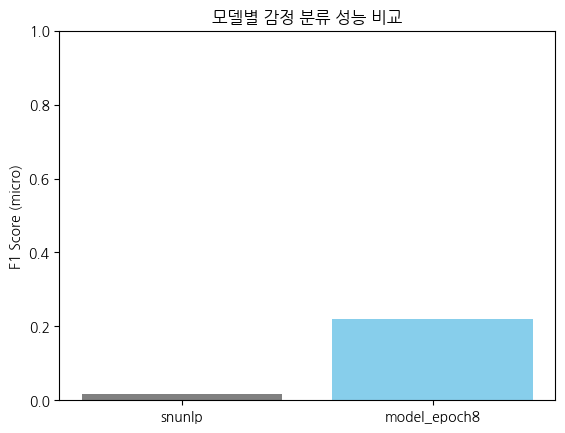

In [44]:
import matplotlib.pyplot as plt

labels = ['snunlp', 'model_epoch8']
scores = [0.0166, 0.2196]

plt.bar(labels, scores, color=['gray', 'skyblue'])
plt.ylim(0, 1)
plt.ylabel("F1 Score (micro)")
plt.title("모델별 감정 분류 성능 비교")
plt.show()


분석


In [45]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
import numpy as np

# ✅ 장치 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ✅ 모델 경로
model_path = "/content/drive/MyDrive/농담터"

# ✅ 토크나이저 및 학습된 모델 로드
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.to(device)
model.eval()

# ✅ 감정 그룹 인덱스 정의
positive_idx = [1, 2, 4, 8, 14, 15, 16, 19, 33, 41, 42, 43]
negative_idx = [0, 3, 5, 6, 10, 12, 20, 21, 22, 23, 25, 26, 27, 36, 38, 40]
neutral_idx  = [7, 9, 11, 13, 17, 18, 24, 28, 29, 30, 31, 32, 34, 35, 37, 39]

# ✅ 댓글 데이터 불러오기
df = pd.read_csv(f"{model_path}/only_comment.csv")

# ✅ 예측 결과 저장 리스트
all_preds = []
all_summary = []

# ✅ 댓글별 예측 실행
for comment in tqdm(df["comment"], desc="Predicting"):
    # 토큰화
    inputs = tokenizer(comment, return_tensors="pt", truncation=True, padding=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.sigmoid(logits).cpu().numpy()[0]  # 확률값 (0~1)

        preds = (probs > 0.5).astype(int).tolist()  # 0.5 초과 → 해당 감정 있음
        all_preds.append(preds)

        # 요약 감정 분류
        pos_score = sum([preds[i] for i in positive_idx])
        neg_score = sum([preds[i] for i in negative_idx])
        neu_score = sum([preds[i] for i in neutral_idx])

        if pos_score >= neg_score and pos_score >= neu_score:
            summary = "긍정"
        elif neg_score >= pos_score and neg_score >= neu_score:
            summary = "부정"
        else:
            summary = "중립"

        all_summary.append(summary)

# ✅ 결과 저장
df["predicted"] = all_preds
df["summary_emotion"] = all_summary

df.to_csv(f"{model_path}/real_predicted_result.csv", index=False)

print("\n✅ 전체 예측 완료! real_predicted_result.csv 로 저장됨")


Predicting: 100%|██████████| 12125/12125 [02:33<00:00, 78.78it/s]


✅ 전체 예측 완료! real_predicted_result.csv 로 저장됨


# 파이차트 시각화

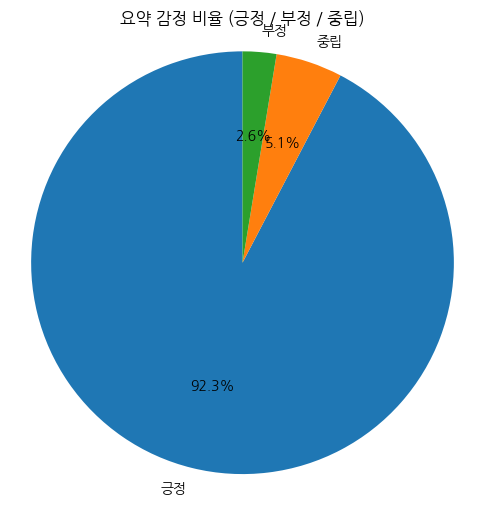

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# ✅ 예측 결과 불러오기
model_path = "/content/drive/MyDrive/농담터"
df = pd.read_csv(f"{model_path}/predicted_result.csv")

# ✅ summary_emotion 컬럼에서 비율 계산
emotion_counts = df["summary_emotion"].value_counts()
labels = emotion_counts.index
sizes = emotion_counts.values

# ✅ 시각화 - 파이차트 (원형 그래프)
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("요약 감정 비율 (긍정 / 부정 / 중립)")
plt.axis("equal")  # 원형 유지
plt.show()


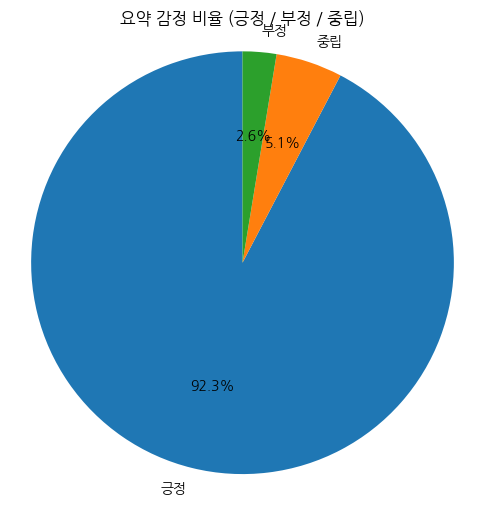

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# ✅ 예측 결과 불러오기
model_path = "/content/drive/MyDrive/농담터"
df = pd.read_csv(f"{model_path}/1predicted_result.csv")

# ✅ summary_emotion 컬럼에서 비율 계산
emotion_counts = df["summary_emotion"].value_counts()
labels = emotion_counts.index
sizes = emotion_counts.values

# ✅ 시각화 - 파이차트 (원형 그래프)
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("요약 감정 비율 (긍정 / 부정 / 중립)")
plt.axis("equal")  # 원형 유지
plt.show()
